# Práctica 2: Modelo cinemático inverso de un manipulador y planteamiento de trayectoria


## Objetivo



El objetivo de esta práctica es que el alumno comprenda, interprete y modifique el modelo de cinemática directa e inversa de un moanipulador serial.


### Metas 

- Que el alumno aplique un modelo cinemático, obteniendo las matrices de transformación y la postura del manipulador 
- Que el alumno aplique un modelo cinemático inverso para calcular una trayectoria a partir de una posición actual hacia una posición final
- Que el alumno grafique y analice los resultados del modelo

### Contribución al perfil del egresado

La siguiente práctica contribuye en los siguientes puntos al perfil del egresado:

#### Aptitudes y habilidades

- Para modelar, simular e interpretar el comportamiento de los sistemas mecatrónicos.
- Para diseñar, construir, operar y mantener los sistemas mecatrónicos y sus componentes.

#### Actitudes

- Tener confianza en su preparación académica.
- Comprometido con su actualización, superación y competencia profesional.

#### De tipo social

- Promover el cambio en la mentalidad frente a la competitividad internacional.



## Rúbrica de evaluación



La evaluación de la práctica contará de los siguientes puntos y se evaluará con los siguientes criterios:

| Elemento | Porcentaje |
| ------:| -----------:|
| **Cuestionario previo** | 15% | 
| **Desarrollo** | 35% |
| **Análisis de resultados**  | 35% |
| **Conclusiones** | 15% |

<br>


| Elemento | Malo | Regular | Bueno |
| ------:| ------ | --------| ------|
| **Cuestionario previo** | El trabajo no contiene cuestionario previo o todas las preguntas son incorrectas (0%)| Al menos la mitad de las preguntas son correctas (8%) |  Todas las preguntas son correctas (15%) |
| **Desarrollo** | El trabajo no contiene desarrollo o su planteamiento no concuerda con lo deseado (0%) | El desarrollo está mal planteado o no llega a los resultados esperados (10%) | El desarrollo tiene un planteamiento adecuado y llega a los resultados esperados (35%) |
| **Análisis de resultados**  | El trabajo no contiene análisis de resultados o la información no se está interpretando correctamente (0%) | La interpretación de los resultados es parcial o desorganizada (10%) | Realiza un correcto análisis de los resultados de forma organizada   (35%) |
| **Conclusiones** | El trabajo no contiene conclusiones o no hacen referencia al trabajo desarrollado y los objetivos planteados (0%) | La redacción de las conclusiones es desorganizada o confusa (8%) | Las conclusiones del trabajo son claras y hacen referencia al trabajo desarrollado y los objetivos planteados (15%) | 



## Introducción

### Transformaciones homogéneas
Las transformaciones homogéneas permiten hacer el planteamiento del modelo cinemático de un robot, considerando las posiciones y orientaciones de las juntas del robot respecto al sistema de referencia de una junta anterior

Este planteamiento es el **modelo de cinemática directa**, que nos permite obtener la posición y velocidad del efector final de un manipulador en términos de los valores de la posición y velocidad de sus juntas (espacio de trabajo)

A través de este modelo se puede obtener el **modelo de cinemática inversa**, que permite obtener la velocidad de las juntas de un robot a partir de la velocidad deseada del efector final.

### Planteamiento de una trayectoria
Si se conoce el punto inicial y final de una trayectoria deseada, se pueden obtener los puntos intermedios de la trayectoria. La forma más fácil de realizar esta interpolación es a través de un spline. El orden del spline permitirá controlar las condiciones inicial y final de la posición, velocidad ó aceleración que tendrá el efector final durante el trayecto. 

Juntando la interpolación de la trayectoria y el modelo de la cinemática inversa, se pueden obtener todos los puntos intermedios de la trayectoria que deben seguir las juntas del robot para que el efector final siga una trayectoria.

### Inyección de dependencias en python
Al crear una clase, es posible agregar atributos y métodos a la misma, que se verán reflejados al instanciar un objeto, por ejemplo:

In [8]:
# Se define una clase
class ClaseEjemplo():
  def metodo_original(self):
    print("Metodo original")
# Fuera de la clase, se define un método nuevo
def metodo_inyectado(self):
  print("Método inyectado en la clase")
# Se asigna el método dentro de la clase
ClaseEjemplo.nuevo_metodo = metodo_inyectado
# Al instanciar el objeto, éste contiene el método inyectado
objeto = ClaseEjemplo()
objeto.nuevo_metodo()

Método inyectado en la clase


## Cuestionario previo



Responder de forma breve las siguientes preguntas:

- ¿Que son las transformaciones homogéneas?
>Las matrices de transformaciones homogéneas son operaciones matemáticas utilizadas en robótica y en computacion grafica para describir la posición y orientación de un objeto en el espacio tridimensional. Su principal ventaja es que unifica en una sola matriz de 4x4 las traslaciones y rotaciones, dirminullendo engran medida las operaciones realziar.

- ¿Que nos permite obtener el modelo de cinemática directa de un manipulador?
>Nos permite obtener la posicion exacta del ultimo eslabon u efector final a partir de la posicion de los eslabones, siendo necessario conocer la posicion y oriebtacion de todas las articulaciones anteriores.

- ¿Que nos permite obtener el modelo de cinemática inversa de un manipulador?
>A diferencia de la directa, en la inversa, a partir de punto y orientacion objetivo para el actuador final, se calculan las pociciones necesarias para las articulaciones que den como resultado la orientacion y posicion dada.

- ¿De que formas se puede interpolar la trayectoria de un efector final entre dos puntos?
> Se puede realizar de dos formas diferentes, mediante interpolaciones en el espacio cartesiano y articular. Para la primera forma, La trayectoria se calcula directamente en coordenadas del mundo real, causando que la trayectoria del efector final es predecible y visualmente directa, a pesar de esto exige resolver la cinemática inversa en cada punto interpolado, lo que requiere mayor potencia de cómputo y puede generar singularidades matemáticas donde el robot se bloquea. Mientras que el enfoque articular, los puntos cartesianos inicial y final se transforman primero en ángulos articulares y  la interpolación se aplica directamente a los motores, la principal ventaja es que es computacionalmente más eficiente y asegura que los límites físicos (velocidad/aceleración máxima de cada articulación) no sean superados. a pesar de esto, la trayectoria real descrita por el efector final en el espacio de trabajo no es una línea recta, sino una curva compleja.

## Desarrollo



### 1. Planteamiento de la cinemática directa
En esta primera parte, se crearán las transformaciones homogéneas y el modelo de cinemática directa de un robot RRR, incluyendo la matriz del Jacobiano. Se recomienda usar **Sympy** para el planteamiento de las expresiones. 
Un diagrama del robot se muestra en la imagen:

<img src="imagenes/p2_1.png" alt = "Robot RRR" width="300" height="300" display= "block"/>

** Considerar valores cualesquiera para las dimensiones de los eslabones y la posición inicial de las juntas

In [43]:
from sympy import *
import matplotlib.pyplot as plt
class Robot():
    pass

In [44]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente
def __init__(self, 
               l:tuple[float]=(0.6, 0.3, 0)):
    th1, th2, th3 = symbols("theta_1,theta_2,theta_3")

    T_0_1 = self.tr_h(gamma=0.1,
                     beta=th1)
    T_1_2 = self.tr_h(x = l[0],
                      beta=th2)
    T_2_3 = self.tr_h(x = l[1],
                      beta=th3)
    T_3_p = self.tr_h(x=l[2])

    T_0_p = T_0_1 * T_1_2 * T_2_3 * T_3_p
    T_0_p = simplify(T_0_p)
    
    # Vector de postura
    xi_0_p = Matrix([T_0_p[0, 3],
                     T_0_p[2, 3],
                     th1 + th2 + th3])
    
    # Jacobiano
    J = Matrix([[diff(xi_0_p, th1),
                 diff(xi_0_p, th2),
                 diff(xi_0_p, th3)]])
    
    J_inv = J.inv()

 # Almacenar variables en el objeto
    self.th1, self.th2, self.th3 = th1, th2, th3
    self.xi_0_p = xi_0_p
    self.J = J
    self.J_inv = J_inv
      
def tr_h(self, x=0, y=0, z=0,
                 gamma=0, beta=0, alpha=0):
    t_x = Matrix([[1,          0,           0, x],
                  [0, cos(gamma), -sin(gamma), 0],
                  [0, sin(gamma),  cos(gamma), 0],
                  [0,          0,           0, 1]])
    t_y = Matrix([[ cos(beta),          0, sin(beta), 0],
                  [         0,          1,         0, y],
                  [-sin(beta),          0, cos(beta), 0],
                  [         0,          0,         0, 1]])
    t_z = Matrix([[cos(alpha), -sin(alpha), 0, 0],
                  [sin(alpha),  cos(alpha), 0, 0],
                  [         0,           0, 1, z],
                  [         0,           0, 0, 1]])
    tr = simplify(t_x * t_y * t_z)
    return tr

Robot.__init__=__init__
Robot.tr_h=tr_h

### 2. Planteamiento de la trayectoria

En esta segunda parte, se planteará el código que permita definir los puntos intermedios de una trayectoria, la cual debe tener velocidades y aceleraciones nulas al inicio y al final. Se deben incluir también las gráficas de la posición, velocidad y aceleración del efector final. 

Calcular la trayectoria considerando de forma general tiempo de duración, puntos inicial y final, y con una tasa de muestreo de 30 muestras por segundo. 

In [45]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente
def m2_Vel_Acel (self):

    # Velocidades del E.F. como variables
    x_dot, z_dot, beta_dot = symbols("x_dot, z_dot, beta_dot")
    # Construir polinomio lambda
    t = symbols("t")
    a_0, a_1, a_2, a_3, a_4, a_5 = symbols("a_0, a_1, a_2, a_3, a_4, a_5")
    lam = a_0 + a_1 * t + a_2 * t**2 + a_3 * t**3 + a_4 * t**4 + a_5 * t**5    
    lam_dot = diff(lam, t)
    lam_dot_dot = diff(lam_dot, t)
    
    # Almacenar variables en el objeto
    self.x_dot, self.z_dot, self.beta_dot = symbols("x_dot, z_dot, beta_dot")
    self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5 = a_0, a_1, a_2, a_3, a_4, a_5
    self.t = t
    self.lam, self.lam_dot, self.lam_dot_dot = lam, lam_dot, lam_dot_dot

def def_tray(self, th_i:tuple[float]=(0.1, 0.1, 0.1), t_f:float=2, frec:float=30,  
            xi_f:tuple[float]=(0.6, 0.1, 0)):
    
    # Posición del efector final substituyendo en la postura (m, rad)
    xi_i = self.xi_0_p.subs({self.th1: th_i[0], 
                             self.th2: th_i[1], 
                             self.th3: th_i[2]})
    # Muestreo y dt
    self.dt = 1.0/frec
    self.muestras = t_f * frec + 1

    #Eq. de restricción para trayectoria
    eq1 = self.lam.subs({self.t: 0})
    eq2 = self.lam.subs({self.t: t_f}) - 1
    eq3 = self.lam_dot.subs({self.t: 0})
    eq4 = self.lam_dot.subs({self.t: t_f})
    eq5 = self.lam_dot_dot.subs({self.t: 0})
    eq6 = self.lam_dot_dot.subs({self.t: t_f})

    solutions = solve((eq1, eq2, eq3, eq4, eq5, eq6),
                (self.a_0, self.a_1, self.a_2, self.a_3, self.a_4, self.a_5))
    
    # Sustituyendo solución en polinimio lambda
    lam_s         = self.lam.subs(solutions)
    lam_dot_s     = self.lam_dot.subs(solutions)
    lam_dot_dot_s = self.lam_dot_dot.subs(solutions)
    
    # Ecuación de posiciones, velocidades y aceleraciones.
    xi_f = Matrix([xi_f[0], xi_f[1], xi_f[2]])
    xi_eq         = xi_i + (xi_f - xi_i) * lam_s
    xi_dot_eq     = (xi_f - xi_i) * lam_dot_s
    xi_dot_dot_eq = (xi_f - xi_i) * lam_dot_dot_s
    
    # Arreglos para almacenar muestreo
    # Tiempo
    t_m = Matrix.zeros(1, self.muestras)
    
    # Posición, velocidad y aceleración del E.F.
    xi_m         = Matrix.zeros(3, self.muestras)
    xi_dot_m     = Matrix.zeros(3, self.muestras)
    xi_dot_dot_m = Matrix.zeros(3, self.muestras)

    for i in range(self.muestras):
        t_m[i] = self.dt * i

    # Muestreo E.F.
    for i in range(self.muestras):
        xi_m[:, i]         = xi_eq.        subs({self.t: t_m[i]})
        xi_dot_m[:, i]     = xi_dot_eq.    subs({self.t: t_m[i]})
        xi_dot_dot_m[:, i] = xi_dot_dot_eq.subs({self.t: t_m[i]})
    print(xi_m[:, self.muestras - 1])


    # Impresión de resumen de la trayectoria en consola
    
    print("         RESUMEN DEL PLANTEAMIENTO DE LA TRAYECTORIA")
    
    print(f"Tiempo de duración: {t_f} segundos")
    print(f"Tasa de muestreo:   {frec} muestras por segundo (dt = {self.dt:.4f} s)")
    print(f"Total de puntos:    {self.muestras} muestras")
    print(f"Posición Inicial:   X={xi_i[0]:.4f}, Z={xi_i[1]:.4f}, Beta={xi_i[2]:.4f}")
    print(f"Posición Final:     X={xi_f[0]:.4f}, Z={xi_f[1]:.4f}, Beta={xi_f[2]:.4f}")
    

    # Guardar variables 
    # Efector final
    self.xi_m         = xi_m
    self.xi_dot_m     = xi_dot_m
    self.xi_dot_dot_m = xi_dot_dot_m
   
    # Tiempo
    self.t_m = t_m

def imp_tray(self):
     # GRÁFICA DE POSICIONES DEL EFECTOR FINAL
    fig, (x_g, z_g, be_g) = plt.subplots(nrows = 1, ncols = 3)
    fig.suptitle("Posiciones del efector final")
    x_g.set_title("x")
    z_g.set_title("z")
    be_g.set_title("beta")
    x_g.plot(self.t_m.T,  self.xi_m[0, :].T, color="RED")
    z_g.plot(self.t_m.T,  self.xi_m[1, :].T, color="green")
    be_g.plot(self.t_m.T, self.xi_m[2, :].T, color=(0,0,1))
    plt.show()

    # GRÁFICA DE VELOCIDADES DEL EFECTOR FINAL
    fig_vel, (vx_g, vz_g, vbe_g) = plt.subplots(nrows = 1, ncols = 3)
    fig_vel.suptitle("Velocidades del efector final")
    vx_g.set_title("x_dot")
    vz_g.set_title("z_dot")
    vbe_g.set_title("beta_dot")
    vx_g.plot(self.t_m.T,  self.xi_dot_m[0, :].T, color="darkred")
    vz_g.plot(self.t_m.T,  self.xi_dot_m[1, :].T, color="darkgreen")
    vbe_g.plot(self.t_m.T, self.xi_dot_m[2, :].T, color=(0,0,0.5))
    plt.show()

    # GRÁFICA DE ACELERACIONES DEL EFECTOR FINAL
    fig_ace, (ax_g, az_g, abe_g) = plt.subplots(nrows = 1, ncols = 3)
    fig_ace.suptitle("Aceleraciones del efector final")
    ax_g.set_title("x_ddot")
    az_g.set_title("z_ddot")
    abe_g.set_title("beta_ddot")
    ax_g.plot(self.t_m.T,  self.xi_dot_dot_m[0, :].T, color="orange")
    az_g.plot(self.t_m.T,  self.xi_dot_dot_m[1, :].T, color="purple")
    abe_g.plot(self.t_m.T, self.xi_dot_dot_m[2, :].T, color="magenta")
    plt.show()

Robot.m2_Vel_Acel = m2_Vel_Acel
Robot.def_tray = def_tray
Robot.imp_tray = imp_tray

### 3. Cinemática inversa
A partir del modelo de la cinemática directa, obtener la expresión e la cinemática inversa, que relacione las velocidades de las juntas del robot con la velocidad del efector final. Ya que el modelo de cinemática inversa sólo permite obtener velocidades, obtener también expresiones que permitan obtener la posición de las juntas y sus aceleraciones

In [49]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente
  # ---- Cinemática inversa
def m3_Cinematica_Inversa(self, th_i, xi_dot_m):
    # Velocidades de las juntas como ecuación
    th_dot_eq = self.J_inv * Matrix([self.x_dot, 
                                      self.z_dot,
                                      self.beta_dot])
    # Posición, velocidad y aceleración de las juntas
    th_m         = Matrix.zeros(3, self.muestras)
    th_dot_m     = Matrix.zeros(3, self.muestras)
    th_dot_dot_m = Matrix.zeros(3, self.muestras)

    # Agregar valor conocido
    th_m[:, 0] = Matrix([th_i[0], 
                         th_i[1], 
                         th_i[2]])

    #Muestreo de las juntas
    for i in range(self.muestras):
      # Velocidades
      th_dot_m[:, i] = th_dot_eq.subs({
        self.th1: th_m[0, i],
        self.th2: th_m[1, i],
        self.th3: th_m[2, i],
        self.x_dot:    xi_dot_m[0, i],
        self.z_dot:    xi_dot_m[1, i],
        self.beta_dot: xi_dot_m[2, i]})
      th_dot_m[:, i] = th_dot_m[:, i].evalf()
      if i < self.muestras - 1:
        # Posiciones
        th_m[:, i+1] = th_m[:, i] + th_dot_m[:, i] * self.dt
      if not (i == 0):
        # Aceleración
        th_dot_dot_m[:, i-1] = (th_dot_m[:, i] - th_dot_m[:, i-1]) / self.dt
    
    # Guardar variables 
    # Juntas
    self.th_m         = th_m
    self.th_dot_m     = th_dot_m
    self.th_dot_dot_m = th_dot_dot_m

Robot.m3_Cinematica_Inversa = m3_Cinematica_Inversa

### 4. Aplicación de la cinemática inversa
Finalmente, a partir de los puntos de la trayectoria y el modelo de cinemática inversa, obtener las posiciones, velocidades y aceleraciones de las juntas del robot, así como sus gráficas en función del tiempo

In [50]:
# Colocar y correr el código dentro de estas celdas. 
# Agregar cuantas consideren conveniente
def imp_junt(self):
    # GRÁFICA DE POSICIONES DE LAS JUNTAS
    fig, (th1_g, th2_g, th3_g) = plt.subplots(nrows = 1, ncols = 3)
    fig.suptitle("Posiciones de las juntas")
    th1_g.set_title("th1")
    th2_g.set_title("th2")
    th3_g.set_title("th3")
    th1_g.plot(self.t_m.T,  self.th_m[0, :].T, color="RED")
    th2_g.plot(self.t_m.T,  self.th_m[1, :].T, color="green")
    th3_g.plot(self.t_m.T,  self.th_m[2, :].T, color=(0,0,1))
    plt.show()
    
    # GRÁFICA DE VELOCIDADES DE LAS JUNTAS
    fig_v_junt, (vth1_g, vth2_g, vth3_g) = plt.subplots(nrows = 1, ncols = 3)
    fig_v_junt.suptitle("Velocidades de las juntas")
    vth1_g.set_title("th1_dot")
    vth2_g.set_title("th2_dot")
    vth3_g.set_title("th3_dot")
    vth1_g.plot(self.t_m.T,  self.th_dot_m[0, :].T, color="darkred")
    vth2_g.plot(self.t_m.T,  self.th_dot_m[1, :].T, color="darkgreen")
    vth3_g.plot(self.t_m.T,  self.th_dot_m[2, :].T, color=(0,0,0.5))
    plt.show()

    # GRÁFICA DE ACELERACIONES DE LAS JUNTAS
    fig_a_junt, (ath1_g, ath2_g, ath3_g) = plt.subplots(nrows = 1, ncols = 3)
    fig_a_junt.suptitle("Aceleraciones de las juntas")
    ath1_g.set_title("th1_ddot")
    ath2_g.set_title("th2_ddot")
    ath3_g.set_title("th3_ddot")
    ath1_g.plot(self.t_m.T,  self.th_dot_dot_m[0, :].T, color="orange")
    ath2_g.plot(self.t_m.T,  self.th_dot_dot_m[1, :].T, color="purple")
    ath3_g.plot(self.t_m.T,  self.th_dot_dot_m[2, :].T, color="magenta")
    plt.show()

Robot.imp_junt=imp_junt

Matrix([[0.600000000000000], [0.0999999999999996], [0]])
         RESUMEN DEL PLANTEAMIENTO DE LA TRAYECTORIA
Tiempo de duración: 2 segundos
Tasa de muestreo:   30 muestras por segundo (dt = 0.0333 s)
Total de puntos:    61 muestras
Posición Inicial:   X=0.8910, Z=-0.1189, Beta=0.3000
Posición Final:     X=0.6000, Z=0.1000, Beta=0.0000


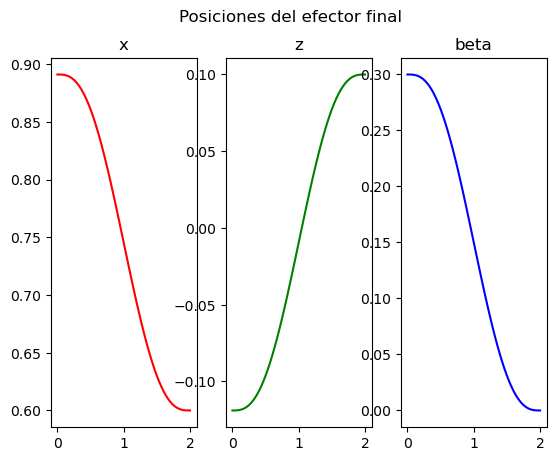

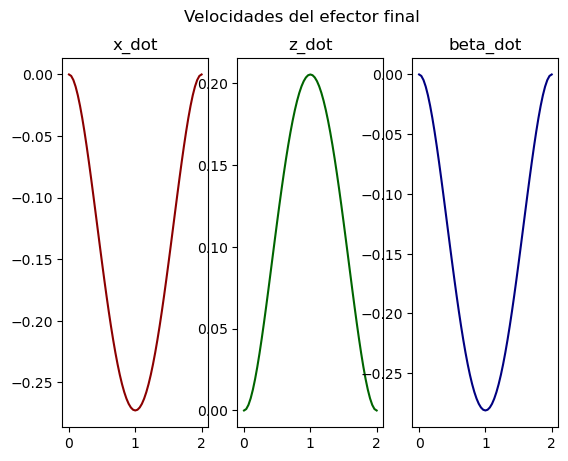

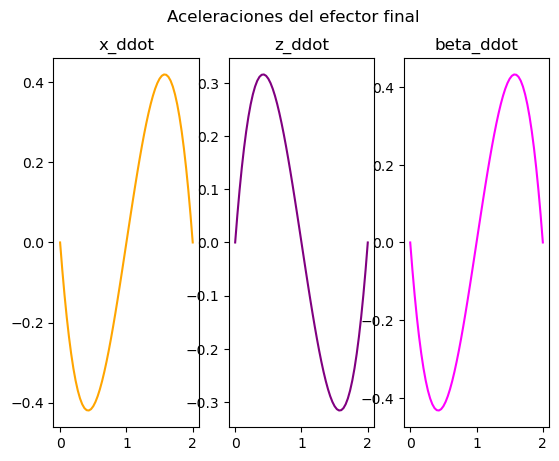

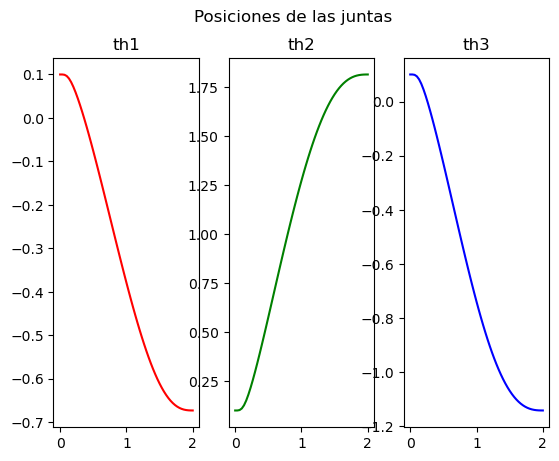

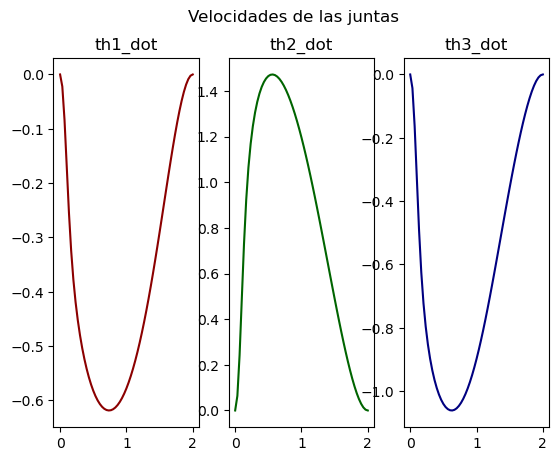

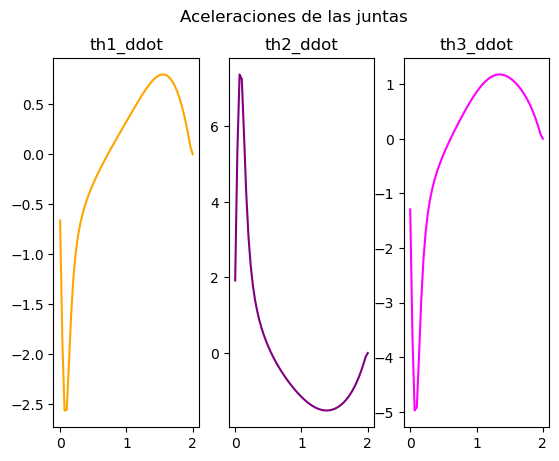

In [51]:
#Declaramos las condiciones iniciales y finales
th_inicial = (0.1, 0.1, 0.1)
xi_final = (0.6, 0.1, 0)

robot = Robot()
robot.__init__()
robot.m2_Vel_Acel()
robot.def_tray(th_i=th_inicial, t_f=2, frec=30, xi_f=xi_final)
robot.imp_tray()
robot.m3_Cinematica_Inversa(th_i=th_inicial, xi_dot_m=robot.xi_dot_m)
robot.imp_junt()

### 5. Repositorio
Para terminar, subir los archivos de la práctica al repositorio de github

## Análisis de resultados



- ¿Qué utilidad tiene el modelo de cinemática inversa de un robot?

> Su función principal es determinar las coordenadas articulares —ya sean ángulos para juntas rotacionales o desplazamientos para prismáticas— que el robot necesita adoptar para que su extremo llegue a una ubicación y orientación específicas en el espacio de trabajo. En pocas palabras, traduce el punto de destino en instrucciones exactas de movimiento para cada uno de los motores.




## Conclusiones



> La obtención de las transformaciones homogéneas y el modelo de cinemática directa son herramientas fundamentales para describir la posición y orientación del efector final en función de las variables de las juntas. Para crear las matrices de transformación, se tuvo que plantear primero la matriz de posición y posteriormente la matriz de rotación; teniendo estas matrices se obtiene el vector de postura, el cual se deriva con respecto a cada variable articular para obtener la matriz del Jacobiano.

> Posteriormente, se implementó el planteamiento de trayectorias mediante la definición de puntos intermedios y la generación de perfiles de movimiento con velocidades y aceleraciones iniciales y finales nulas. Esta condición permite obtener desplazamientos suaves y continuos, reduciendo cambios bruscos en el movimiento y asegurando una transición adecuada entre los diferentes puntos de la trayectoria.

> Finalmente, utilizando las ecuaciones de la cinemática directa y el Jacobiano inverso, se relacionaron las velocidades del efector final con las de las articulaciones, lo que permitió determinar las configuraciones de las juntas necesarias para alcanzar la posición específica del efector final. Con ello se corroboró la relación bidireccional entre ambos modelos y su importancia en la planificación y ejecución de movimientos. Por último, cabe destacar la metodología necesaria para modelar, planificar y controlar el movimiento de un manipulador, ya que integra conceptos fundamentales de robótica que sirven como base para el desarrollo de sistemas de control más avanzados, como el seguimiento de una trayectoria.


## Bibliografía 



[1] J. J. Craig, *Introduction to Robotics: Mechanics and Control*, 4th ed. Upper Saddle River, NJ: Pearson, 2018.

[2] M. W. Spong, S. Hutchinson, y M. Vidyasagar, *Robot Modeling and Control*, 2nd ed. Hoboken, NJ: John Wiley & Sons, 2020.

